# Ridge Regression – House Price Prediction Baseline

This notebook trains a **Ridge Regression** model to predict `Tran_Pri`.  
Feature engineering is adapted for linear models: high‑cardinality composite keys are removed, and only broader location categories are retained. The pipeline uses standardization and one‑hot encoding, with Ridge hyperparameters tuned via time‑series cross‑validation.

## Workflow Summary

- Import libraries and set paths  
- Define parsing and helper functions  
- **Simplified feature engineering for linear regression**  
- Load and split data chronologically  
- Build features for train, holdout, and test  
- Preprocess (standardize numeric, one‑hot encode categorical)  
- Tune Ridge with `GridSearchCV` and `TimeSeriesSplit`  
- Evaluate and save outputs

## 1. Imports and Configuration
This cell imports all required libraries and defines file paths and global constants used throughout the notebook.

In [ ]:
import re
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


# Configuration
TARGET_COLUMN = "Tran_Pri"
RANDOM_STATE = 42
HOLDOUT_SIZE = 0.2

BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR.parent / "data" / "TRAIN.csv"
TEST_PATH = BASE_DIR.parent / "data" / "TEST.csv"
OUTPUT_DIR = BASE_DIR / "outputs_ridge"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Training file exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test file exists:", TEST_PATH.exists(), TEST_PATH)

Base directory: d:\MACHINE LEARNING\knn_catboost\linear
Training file exists: True d:\MACHINE LEARNING\knn_catboost\data\TRAIN.csv
Test file exists: True d:\MACHINE LEARNING\knn_catboost\data\TEST.csv


## 2. Helper Functions
These utility functions are reused from the CatBoost notebook. They parse text‑heavy columns and handle chronological splitting.

In [4]:
def parse_layout(layout: str) -> tuple[int, int, int, int]:
    """Extract room, livingroom, kitchen, and bathroom counts from layout text."""
    text = str(layout)
    counts = {}
    for part in ["Room", "Livingroom", "Kitchen", "Bathroom"]:
        match = re.search(rf"(\d+){part}", text)
        counts[part] = int(match.group(1)) if match else 0
    return (counts["Room"], counts["Livingroom"], counts["Kitchen"], counts["Bathroom"])

def parse_ea_ratio(value: str) -> tuple[float, float]:
    """Extract elevator and apartment counts from strings like '2E4A'."""
    match = re.match(r"(\d+)E(\d+)A", str(value))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))

def time_holdout_split(df: pd.DataFrame, holdout_size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Chronological split using Tran_Dt."""
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    ordered_df = df.assign(_tran_dt=tran_dt).sort_values("_tran_dt").drop(columns="_tran_dt")
    split_idx = int(len(ordered_df) * (1 - holdout_size))
    return ordered_df.iloc[:split_idx].copy(), ordered_df.iloc[split_idx:].copy()

def calculate_metrics(actual: pd.Series, predicted: np.ndarray) -> dict:
    """Return RMSE, MAE, and R²."""
    return {
        "rmse": float(root_mean_squared_error(actual, predicted)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }

## 3. Feature Engineering – Simplified for Linear Regression
This function creates features suitable for a linear model. High‑cardinality keys like Neigh and composite location keys are dropped to avoid an explosion of one‑hot encoded columns. Numeric transformations (e.g., log area) are retained to capture non‑linear relationships.

In [ ]:
def build_features_linear(df: pd.DataFrame, area_clip_bounds: tuple = None) -> tuple[pd.DataFrame, pd.Series, list, tuple]:
    
    #Create features suitable for linear regression.
    # Keeps numeric features and log transforms.
    # Drops high‑cardinality keys (Neigh, Location_Key, etc.) to avoid dimension explosion.
    # Retains broader categoricals: City, Reg, Dist, Build_Type, etc.
    
    df = df.copy()
    
    # Parse date
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    df["Tran_Year"] = tran_dt.dt.year
    df["Tran_Month"] = tran_dt.dt.month
    
    # Clean build year and age
    built_year = pd.to_numeric(df["Build_Yr_Filled"], errors="coerce").clip(lower=1900, upper=2035)
    built_year = built_year.where(built_year <= df["Tran_Year"], df["Tran_Year"])
    df["Property_Age"] = (df["Tran_Year"] - built_year).clip(lower=0, upper=120)
    
    # Floor area clipping and log
    area = pd.to_numeric(df["Flo_Area"], errors="coerce")
    if area_clip_bounds is None:
        area_clip_bounds = (float(area.quantile(0.001)), float(area.quantile(0.995)))
    area_low, area_high = area_clip_bounds
    df["Flo_Area_Clipped"] = area.clip(lower=area_low, upper=area_high)
    df["Log_Flo_Area"] = np.log1p(df["Flo_Area_Clipped"])
    
    # Floor position ordinal
    floor_map = {"Lower floor": 1, "Middle floor": 2, "Upper floor": 3}
    df["Prop_Flo_Code"] = df["Prop_Flo"].map(floor_map).fillna(2)
    
    # Parse layout counts
    layout_parts = df["Layout"].apply(parse_layout)
    df["Layout_Rooms"] = layout_parts.str[0]
    df["Layout_Livingrooms"] = layout_parts.str[1]
    df["Layout_Kitchens"] = layout_parts.str[2]
    df["Layout_Bathrooms"] = layout_parts.str[3]
    
    # Parse elevator/apartment counts
    ea_parts = df["EA_Ratio"].apply(parse_ea_ratio)
    df["Elevator_Count"] = ea_parts.str[0]
    df["Apartment_Count"] = ea_parts.str[1]
    
    # Binary flags
    df["Lift_Flag"] = (df["Lift"].astype(str) == "Yes").astype(int)
    df["Has_Renovation"] = (df["ReNov"].astype(str) != "Unfurnished").astype(int)
    
    # Drop raw columns not used as features
    drop_cols = [
        "Tran_Dt", "Tran_Day", "Build_Yr", "Layout", "Prop_Flo",
        "Neigh",                           # too many categories
        "EA_Ratio", "Build_Yr_Filled", "Elevator_Density",
        "Total_Rooms",                     # redundant with Layout_Rooms
        "Tran_Year", "Tran_Month"          # keep only if needed; we drop for simplicity
    ]
    
    # Target
    y = df[TARGET_COLUMN].copy()
    
    # Features
    X = df.drop(columns=[TARGET_COLUMN] + [c for c in drop_cols if c in df.columns], errors='ignore')
    
    # Identify categorical columns – only broader ones
    categorical_columns = [
        "City", "Reg", "Dist", "Build_Type", "Orient", "ReNov",
        "Build_Str", "Lift", "Prop_Type", "Build_Pur"
    ]
    # Keep only those present
    categorical_columns = [c for c in categorical_columns if c in X.columns]
    
    # Fill missing and convert to string for encoding
    for col in categorical_columns:
        X[col] = X[col].fillna("Missing").astype(str)
    
    return X, y, categorical_columns, area_clip_bounds

## 4. Load Data and Split
Load the raw CSV files and create a time‑based holdout split (80% train, 20% holdout) to simulate real‑world forecasting.

In [6]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_split_df, holdout_df = time_holdout_split(train_df, HOLDOUT_SIZE)

print("Train period:", train_split_df["Tran_Dt"].iloc[0], "to", train_split_df["Tran_Dt"].iloc[-1])
print("Holdout period:", holdout_df["Tran_Dt"].iloc[0], "to", holdout_df["Tran_Dt"].iloc[-1])
print("Test period:", test_df["Tran_Dt"].iloc[0], "to", test_df["Tran_Dt"].iloc[-1])

Training shape: (165808, 23)
Test shape: (62733, 23)
Train period: 2012.11.22 to 2021.02.20
Holdout period: 2021.02.20 to 2021.06.30
Test period: 2021.07.01 to 2023.02.13


## 5. Build Features
Apply the feature engineering function to all three splits. The clipping bounds for floor area are computed on the training split and reused for holdout and test to prevent leakage.

In [7]:
X_train, y_train, categorical_columns, area_clip_bounds = build_features_linear(train_split_df)
X_holdout, y_holdout, _, _ = build_features_linear(holdout_df, area_clip_bounds)
X_test, y_test, _, _ = build_features_linear(test_df, area_clip_bounds)

print("X_train shape:", X_train.shape)
print("X_holdout shape:", X_holdout.shape)
print("X_test shape:", X_test.shape)
print("Categorical columns:", categorical_columns)

X_train shape: (132646, 24)
X_holdout shape: (33162, 24)
X_test shape: (62733, 24)
Categorical columns: ['City', 'Reg', 'Dist', 'Build_Type', 'Orient', 'ReNov', 'Build_Str', 'Lift', 'Prop_Type', 'Build_Pur']


## 6. Preprocessing and Ridge Tuning
Build a pipeline that imputes missing values, standardizes numeric features, one‑hot encodes categorical features, and applies Ridge regression. Hyperparameter alpha is tuned using TimeSeriesSplit cross‑validation to respect chronological order.

In [8]:
# Separate numeric and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Numeric pipeline: median impute + standardize
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: constant fill + one‑hot encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_columns)
])

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=RANDOM_STATE))
])

# Time‑series cross‑validation
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter grid for Ridge alpha
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV score (negative MAE):", grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best alpha: {'regressor__alpha': 1.0}
Best CV score (negative MAE): -663.3068221677273


## 7. Generate Predictions and Compute Metrics
Use the tuned model to predict prices on train, holdout, and test sets. Calculate RMSE, MAE, and R² for each split.

In [9]:
train_pred = best_model.predict(X_train)
holdout_pred = best_model.predict(X_holdout)
test_pred = best_model.predict(X_test)

split_metrics = {
    "train": {"rows": len(X_train), **calculate_metrics(y_train, train_pred)},
    "holdout": {"rows": len(X_holdout), **calculate_metrics(y_holdout, holdout_pred)},
    "test": {"rows": len(X_test), **calculate_metrics(y_test, test_pred)},
}

comparison_df = pd.DataFrame.from_dict(split_metrics, orient="index").reset_index().rename(columns={"index": "split"})
comparison_df = comparison_df[["split", "rows", "rmse", "mae", "r2"]]
comparison_df

,split,rows,rmse,mae,r2
0,train,132646,864.938310,531.422573,0.700222
1,holdout,33162,1058.793711,596.824337,0.656547
2,test,62733,1152.665982,603.113566,0.646596


## 8. Save Outputs
Persist the trained model, preprocessing parameters, metrics, and predictions to disk for later reuse and reporting.

In [10]:
# Save model and preprocessing info
joblib.dump(best_model, OUTPUT_DIR / 'ridge_price_model.joblib')

preprocessing_info = {
    "feature_columns": X_train.columns.tolist(),
    "categorical_columns": categorical_columns,
    "numeric_features": numeric_features,
    "area_clip_bounds": area_clip_bounds,
    "target_column": TARGET_COLUMN,
}
with open(OUTPUT_DIR / 'preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

# Save metrics
comparison_df.to_csv(OUTPUT_DIR / 'metrics_comparison.csv', index=False)

# Save predictions
test_predictions_df = pd.DataFrame({"actual": y_test, "predicted": test_pred})
test_predictions_df.to_csv(OUTPUT_DIR / 'actual_vs_predicted.csv', index=False)

# Save test file with predictions
test_with_pred = test_df.copy()
test_with_pred['predicted_tran_pri'] = test_pred
test_with_pred['residual'] = y_test - test_pred
test_with_pred.to_csv(OUTPUT_DIR / 'test_full_with_predictions.csv', index=False)

print("All outputs saved to:", OUTPUT_DIR)

All outputs saved to: d:\MACHINE LEARNING\knn_catboost\linear\outputs_ridge


## 9. Generate Evaluation Charts
Create and save three diagnostic plots: (1) scatter plot of actual vs predicted test prices, (2) histogram of residuals, and (3) bar chart comparing metrics across splits.

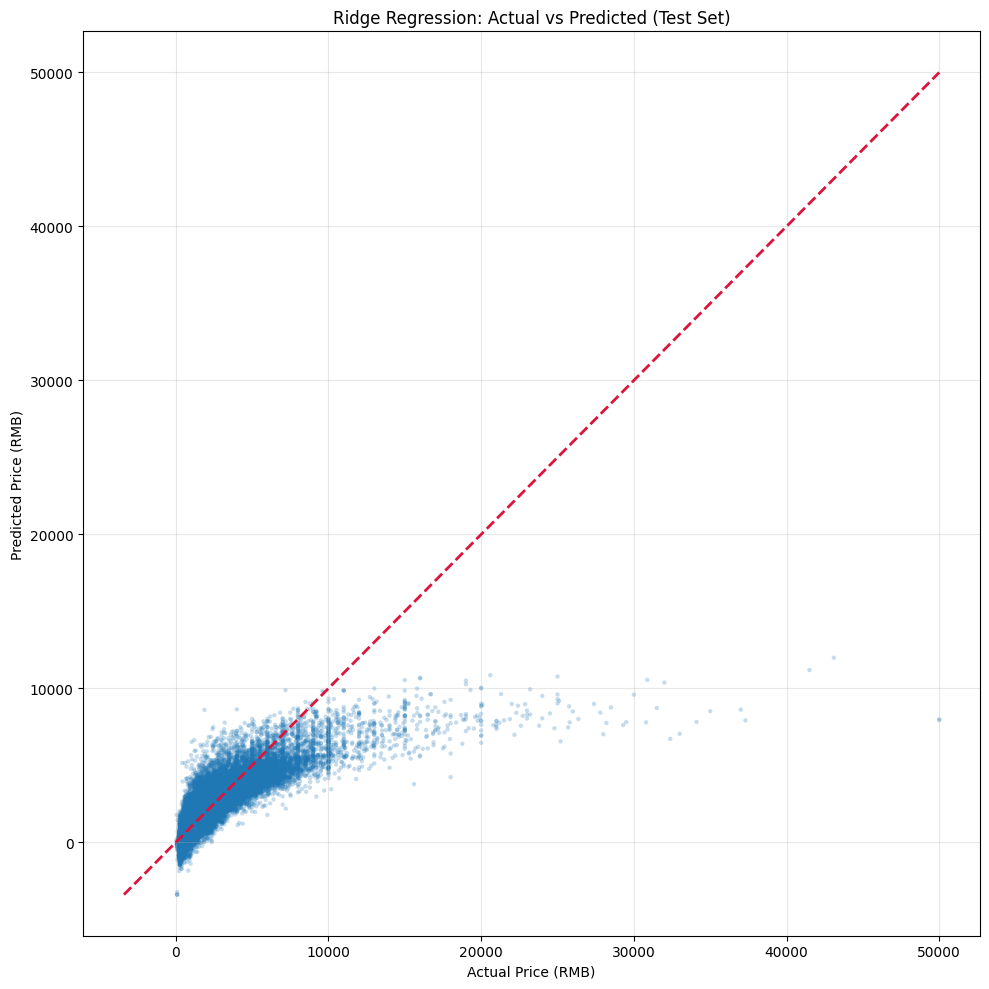

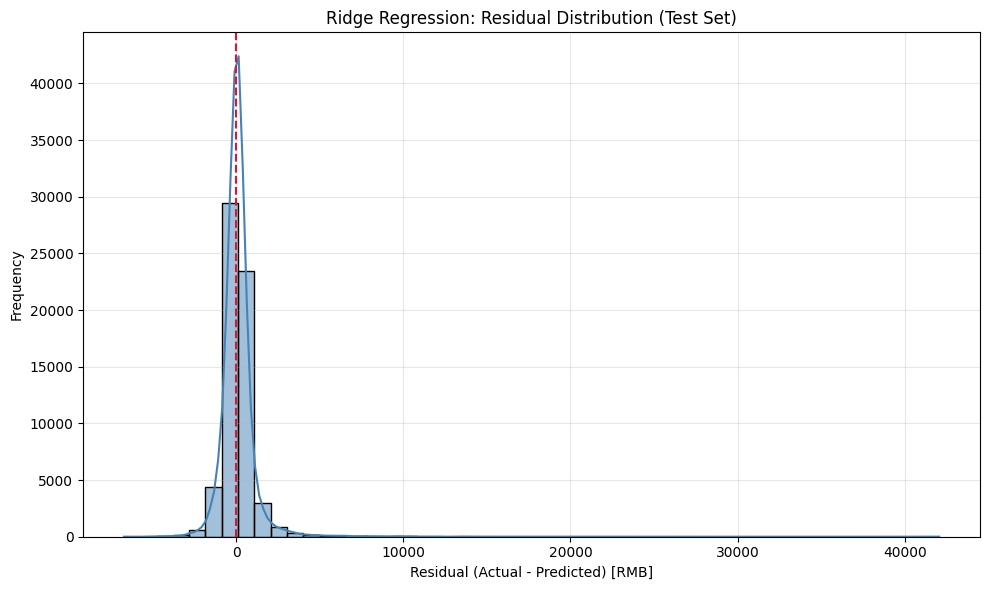

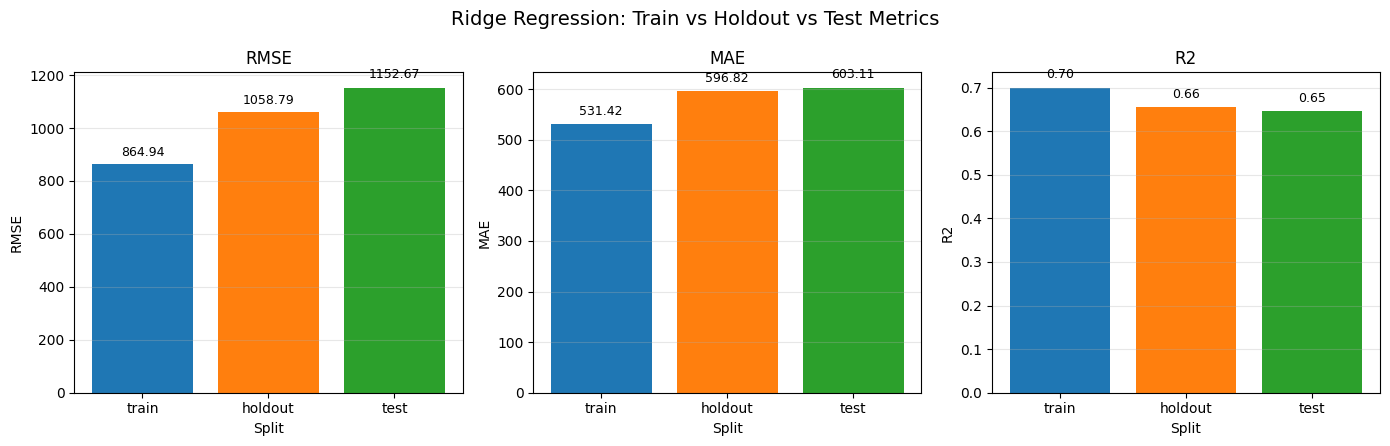

Charts saved to: d:\MACHINE LEARNING\knn_catboost\linear\outputs_ridge


In [ ]:
# Cell: Generate Evaluation Charts for Ridge Regression
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Scatter Plot: Actual vs Predicted (Test Set)
plt.figure(figsize=(10, 10))
plt.scatter(y_test, test_pred, alpha=0.25, s=10, edgecolors='none', rasterized=True)
min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', linewidth=2, color='crimson')
plt.xlabel('Actual Price (RMB)')
plt.ylabel('Predicted Price (RMB)')
plt.title('Ridge Regression: Actual vs Predicted (Test Set)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted_scatter.png', dpi=220)
plt.show()
plt.close()


# 2. Histogram of Residuals (Test Set)
residuals = y_test - test_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Residual (Actual - Predicted) [RMB]')
plt.ylabel('Frequency')
plt.title('Ridge Regression: Residual Distribution (Test Set)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_histogram.png', dpi=220)
plt.show()
plt.close()


# 3. Bar Chart: Metrics Comparison (Train / Holdout / Test)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = ['rmse', 'mae', 'r2']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, metric in zip(axes, metrics):
    ax.bar(comparison_df['split'], comparison_df[metric], color=colors)
    ax.set_title(metric.upper())
    ax.set_xlabel('Split')
    ax.set_ylabel(metric.upper())
    ax.grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        ax.text(i, v + 0.02 * v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Ridge Regression: Train vs Holdout vs Test Metrics', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_bars.png', dpi=220)
plt.show()
plt.close()

print("Charts saved to:", OUTPUT_DIR)

## 10. Feature Importances
Coefficient-based Feature Importance – absolute value of standardized coefficients.

SHAP Feature Importance – using shap.LinearExplainer for fast, exact SHAP values.

Partial Dependence Plots (PDP) – for the top numeric features.

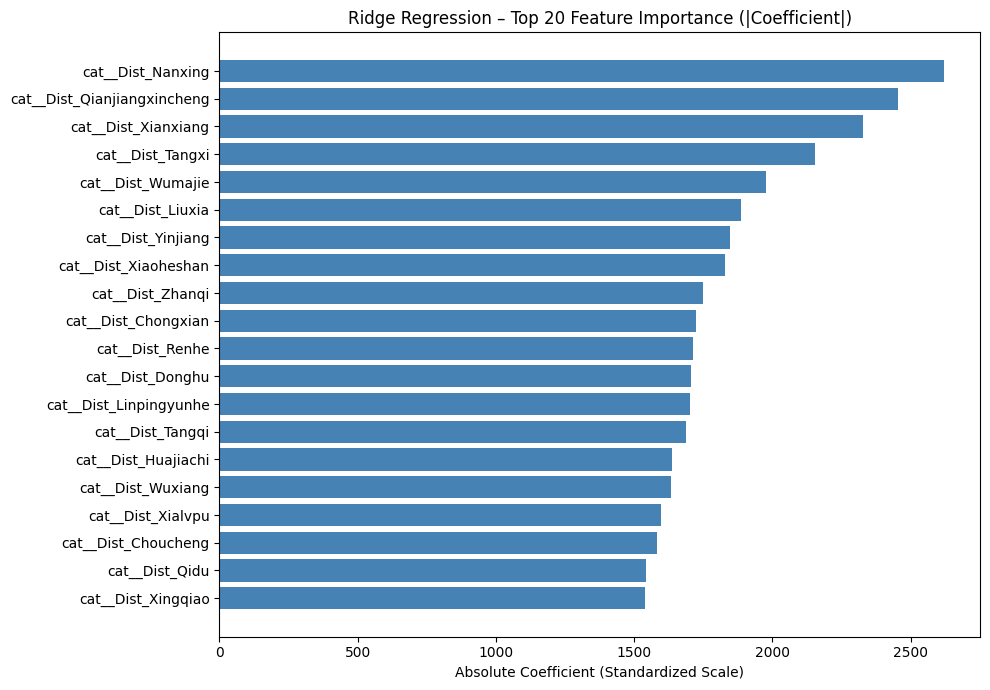

Coefficient importance saved.


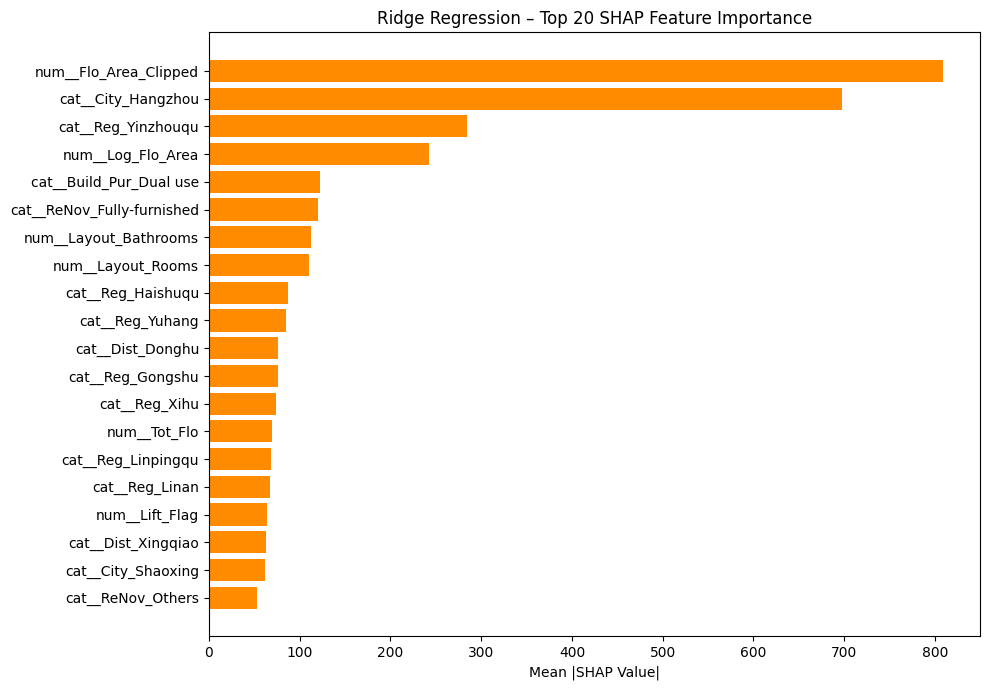

SHAP importance saved.


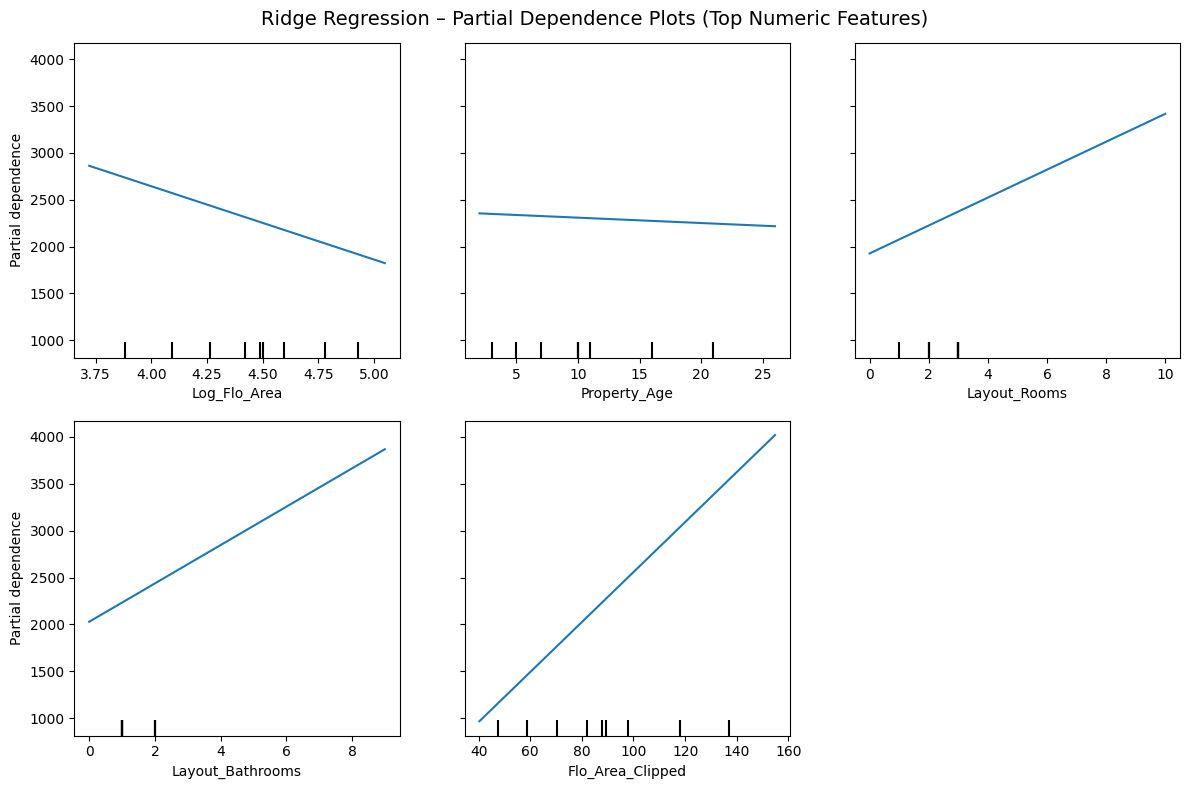

PDP saved to: d:\MACHINE LEARNING\knn_catboost\linear\outputs_ridge\ridge_pdp.png

All interpretability outputs saved.


In [ ]:
# Cell: Interpretability – Feature Importance, SHAP, and PDP for Ridge Regression
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay


# 1. Feature Importance from Ridge Coefficients

# Extract the Ridge model and preprocessor from the pipeline
ridge_model = best_model.named_steps['regressor']
preprocessor = best_model.named_steps['preprocessor']

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefs = ridge_model.coef_

# Create DataFrame of absolute coefficients
coef_importance = pd.DataFrame({
    'feature': feature_names,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

# Save to CSV
coef_importance.to_csv(OUTPUT_DIR / 'ridge_coefficient_importance.csv', index=False)

# Plot top 20
top_n = 20
plot_df = coef_importance.head(top_n).sort_values('abs_coef', ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['abs_coef'], color='steelblue')
plt.xlabel('Absolute Coefficient (Standardized Scale)')
plt.title(f'Ridge Regression – Top {top_n} Feature Importance (|Coefficient|)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ridge_coefficient_importance.png', dpi=220)
plt.show()
plt.close()

print("Coefficient importance saved.")


# 2. SHAP Feature Importance (LinearExplainer)

# Use a small sample from test set for SHAP
sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)

# Preprocess the sample to get the transformed feature matrix
X_sample_transformed = preprocessor.transform(X_sample)

# Create LinearExplainer (exact for linear models)
explainer = shap.LinearExplainer(ridge_model, X_sample_transformed)
shap_values = explainer.shap_values(X_sample_transformed)

# Mean absolute SHAP
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_importance.to_csv(OUTPUT_DIR / 'ridge_shap_importance.csv', index=False)

# Plot top 20 SHAP
plot_shap = shap_importance.head(top_n).sort_values('mean_abs_shap', ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(plot_shap['feature'], plot_shap['mean_abs_shap'], color='darkorange')
plt.xlabel('Mean |SHAP Value|')
plt.title(f'Ridge Regression – Top {top_n} SHAP Feature Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ridge_shap_importance.png', dpi=220)
plt.show()
plt.close()

print("SHAP importance saved.")


# 3. Partial Dependence Plots (PDP) for Top Numeric Features

# Identify top numeric original features (before encoding)
numeric_original = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numeric_original) > 6:
    # Select a few important ones based on coefficient or domain knowledge
    top_numeric = ['Log_Flo_Area', 'Property_Age', 'Layout_Rooms', 'Layout_Bathrooms', 'Flo_Area_Clipped']
    top_numeric = [f for f in top_numeric if f in numeric_original][:5]
else:
    top_numeric = numeric_original[:5]

# Create PDP using scikit-learn
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, top_numeric,
    kind='average', grid_resolution=30, ax=ax, n_jobs=-1
)
plt.suptitle('Ridge Regression – Partial Dependence Plots (Top Numeric Features)', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ridge_pdp.png', dpi=220)
plt.show()
plt.close()

print("PDP saved to:", OUTPUT_DIR / 'ridge_pdp.png')
print("\nAll interpretability outputs saved.")

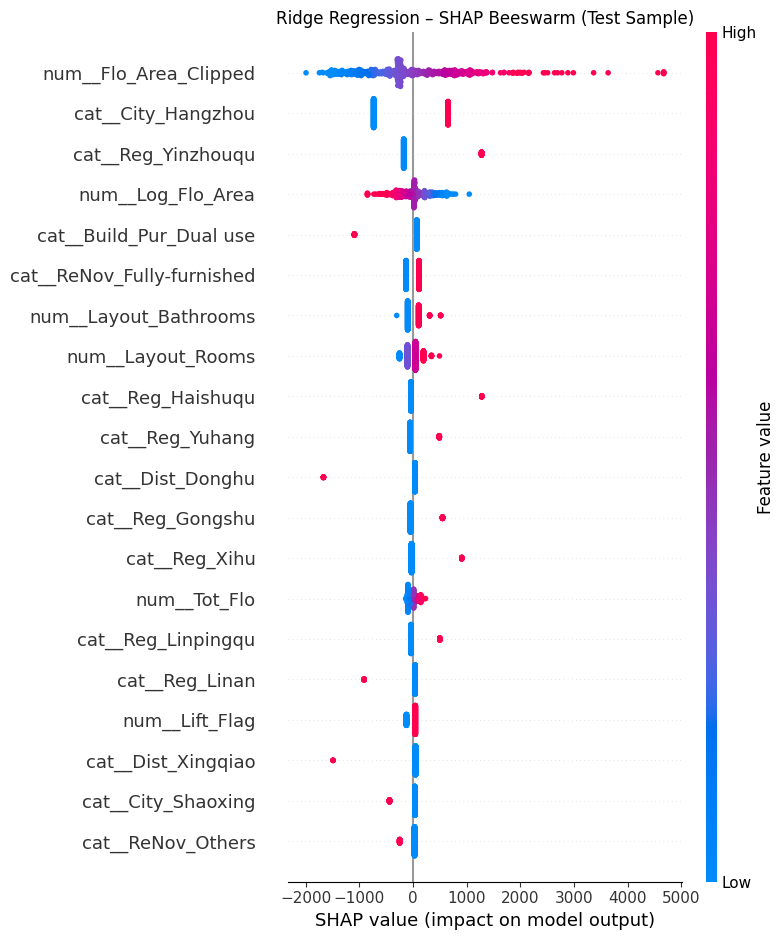

SHAP beeswarm plot saved to: d:\MACHINE LEARNING\knn_catboost\linear\outputs_ridge\ridge_shap_beeswarm.png


In [ ]:

# 1. Prepare a sample of test data
sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)

# Preprocess the sample using the pipeline's preprocessor
X_sample_transformed = preprocessor.transform(X_sample)

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()


# 2. Create LinearExplainer and compute SHAP values
ridge_model = best_model.named_steps['regressor']
explainer = shap.LinearExplainer(ridge_model, X_sample_transformed)
shap_values = explainer.shap_values(X_sample_transformed)


# 3. Create SHAP Explanation object for plotting
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_sample_transformed,
    feature_names=feature_names
)


# 4. Generate Beeswarm Summary Plot
plt.figure()
shap.summary_plot(explanation, X_sample_transformed, plot_type="dot", show=False)
plt.title("Ridge Regression – SHAP Beeswarm (Test Sample)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ridge_shap_beeswarm.png', dpi=220, bbox_inches="tight")
plt.show()
plt.close()

print("SHAP beeswarm plot saved to:", OUTPUT_DIR / 'ridge_shap_beeswarm.png')